# GR00T Inference

This tutorial shows how to use the GR00T inference model to predict the actions from the observations, given a test dataset.

In [1]:
import os
import torch
import gr00t

from gr00t.data.dataset import LeRobotSingleDataset
from gr00t.model.policy import Gr00tPolicy

/home/korea_bupj/rilab/kdy/miniconda3/envs/gr00t/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/korea_bupj/rilab/kdy/miniconda3/envs/gr00t/lib/python3.10/site-packages/albumentations/__init__.py:13: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.18). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()
2026-05-06 22:51:14.006440: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-06 22:51:14.031451: E external/local_xla/xla/stream_execut

In [2]:
# change the following paths
MODEL_PATH = "nvidia/GR00T-N1.5-3B"

# REPO_PATH is the path of the pip install gr00t repo and one level up
REPO_PATH = os.path.dirname(os.path.dirname(gr00t.__file__))
DATASET_PATH = os.path.join(REPO_PATH, "demo_data/robot_sim.PickNPlace")
EMBODIMENT_TAG = "gr1"

device = "cuda" if torch.cuda.is_available() else "cpu"

## Loading Pretrained Policy

Policy Model is loaded just like any other huggingface model.

There are 2 new concepts here in the GR00T model:
 - modality config: This defines the keys in the dictionary used by the model. (e.g. `action`, `state`, `annotation`, `video`)
 - modality_transform: A sequence of transform which are used during dataloading

In [3]:
from gr00t.experiment.data_config import DATA_CONFIG_MAP


data_config = DATA_CONFIG_MAP["fourier_gr1_arms_only"]
modality_config = data_config.modality_config()
modality_transform = data_config.transform()

policy = Gr00tPolicy(
    model_path=MODEL_PATH,
    embodiment_tag=EMBODIMENT_TAG,
    modality_config=modality_config,
    modality_transform=modality_transform,
    device=device,
)

# print out the policy model architecture
print(policy.model)

`use_fast` is set to `True` but the image processor class does not have a fast version.  Falling back to the slow version.
Fetching 13 files: 100%|██████████| 13/13 [00:00<00:00, 140893.93it/s]


Loading pretrained dual brain from /home/korea_bupj/.cache/huggingface/hub/models--nvidia--GR00T-N1.5-3B/snapshots/869830fc749c35f34771aa5209f923ac57e4564e
Tune backbone vision tower: True
Tune backbone LLM: False
Tune action head projector: True
Tune action head DiT: True
Model not found or avail in the huggingface hub. Loading from local path: /home/korea_bupj/.cache/huggingface/hub/models--nvidia--GR00T-N1.5-3B/snapshots/869830fc749c35f34771aa5209f923ac57e4564e
Tune backbone llm: False
Tune backbone visual: True
Total number of DiT parameters:  550386688
Total number of SelfAttentionTransformer parameters:  201433088
Tune action head projector: True
Tune action head diffusion model: True


Loading checkpoint shards: 100%|██████████| 3/3 [00:00<00:00, 35.57it/s]

Tune backbone llm: False
Tune backbone visual: True
Tune action head projector: True
Tune action head diffusion model: True


GR00T_N1_5(
  (backbone): EagleBackbone(
    (eagle_model): Eagle2_5_VLForConditionalGeneration(
      (vision_model): SiglipVisionModel(
        (vision_model): SiglipVisionTransformer(
          (embeddings): SiglipVisionEmbeddings(
            (patch_embedding): Conv2d(3, 1152, kernel_size=(14, 14), stride=(14, 14), padding=valid)
            (position_embedding): Embedding(256, 1152)
          )
          (encoder): SiglipEncoder(
            (layers): ModuleList(
              (0-26): 27 x SiglipEncoderLayer(
                (layer_norm1): LayerNorm((1152,), eps=1e-06, elementwise_affine=True)
                (self_attn): SiglipAttention(
                  (k_proj): Linear(in_features=1152, out_features=1152, bias=True)
                  (v_proj): Linear(in_features=1152, out_features=1152, bias=True)
                  (q_proj): Linear(in_features=1152, out_features=1152, bias=True)
                  (out_proj): Linear(in_features=1152, out_features=1152, bias=True)
              

## Loading dataset

First this requires user to check which embodiment tags are used to pretrained the `Gr00tPolicy` pretrained models.

In [4]:
import numpy as np

modality_config = policy.modality_config

print(modality_config.keys())

for key, value in modality_config.items():
    if isinstance(value, np.ndarray):
        print(key, value.shape)
    else:
        print(key, value)


dict_keys(['video', 'state', 'action', 'language'])
video delta_indices=[0] modality_keys=['video.ego_view']
state delta_indices=[0] modality_keys=['state.left_arm', 'state.right_arm', 'state.left_hand', 'state.right_hand']
action delta_indices=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15] modality_keys=['action.left_arm', 'action.right_arm', 'action.left_hand', 'action.right_hand']
language delta_indices=[0] modality_keys=['annotation.human.action.task_description']


In [5]:
# Create the dataset
dataset = LeRobotSingleDataset(
    dataset_path=DATASET_PATH,
    modality_configs=modality_config,
    video_backend="decord",
    video_backend_kwargs=None,
    transforms=None,  # We'll handle transforms separately through the policy
    embodiment_tag=EMBODIMENT_TAG,
)

Initialized dataset robot_sim.PickNPlace with gr1


In [6]:
dataset.modality_configs

{'video': ModalityConfig(delta_indices=[0], modality_keys=['video.ego_view']),
 'state': ModalityConfig(delta_indices=[0], modality_keys=['state.left_arm', 'state.right_arm', 'state.left_hand', 'state.right_hand']),
 'action': ModalityConfig(delta_indices=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15], modality_keys=['action.left_arm', 'action.right_arm', 'action.left_hand', 'action.right_hand']),
 'language': ModalityConfig(delta_indices=[0], modality_keys=['annotation.human.action.task_description'])}

Let's print out a single data and visualize it

In [7]:
import numpy as np

step_data = dataset[0]
step_data2 = dataset[600]

print(step_data)

print("\n\n ====================================")
for key, value in step_data.items():
    if isinstance(value, np.ndarray):
        print(key, value.shape)
    else:
        print(key, value)


{'video.ego_view': array([[[[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],

        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],

        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],

        ...,

        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],

        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],

        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]]]], dtype=uint8), 'state.left_arm': array([[-0.01147083,  0.12207967,  0.04229397, -2.1       , -0.01441445,
        -0.03013532, -0.00384387]]), 'state.r

Let's plot just the "right hand" state and action data and see how it looks like. Also show the images of the right hand state.

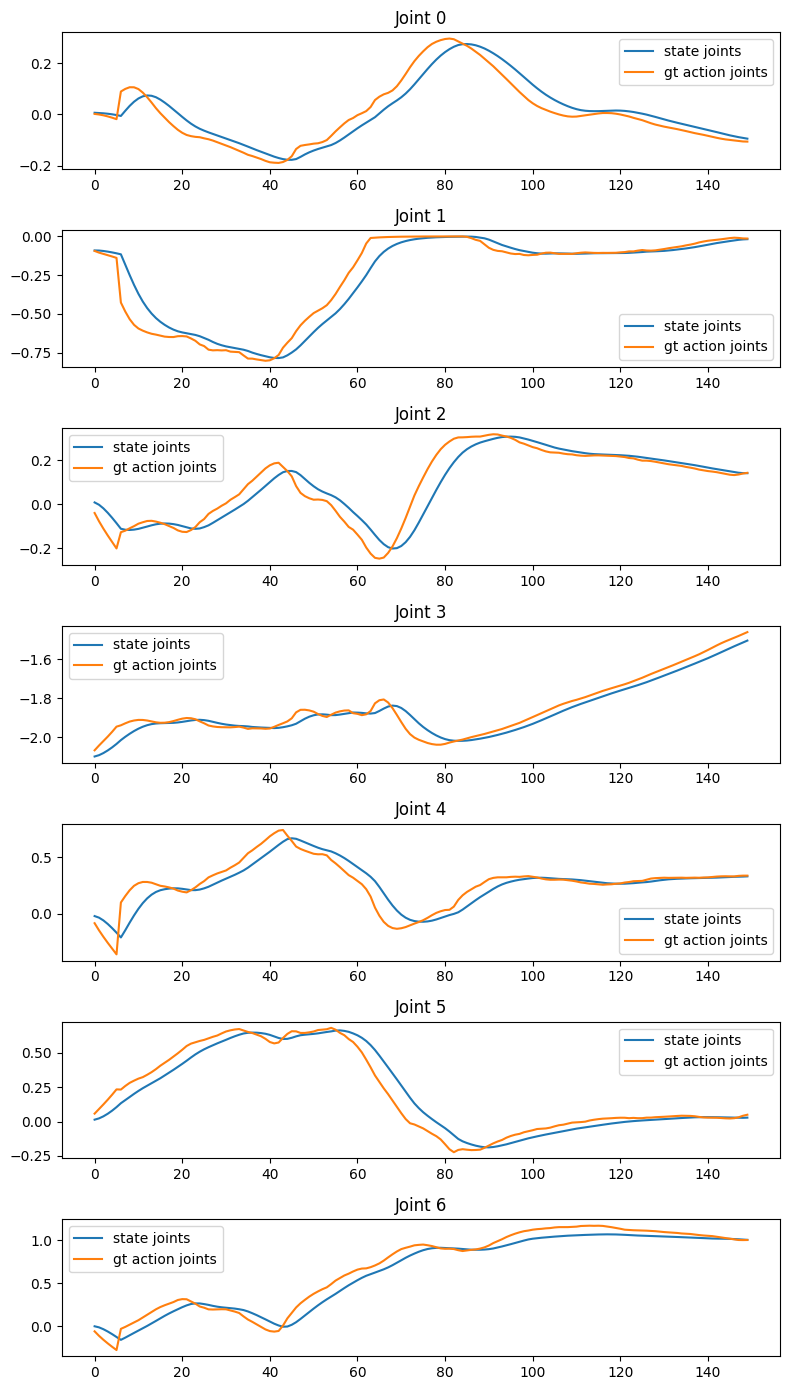

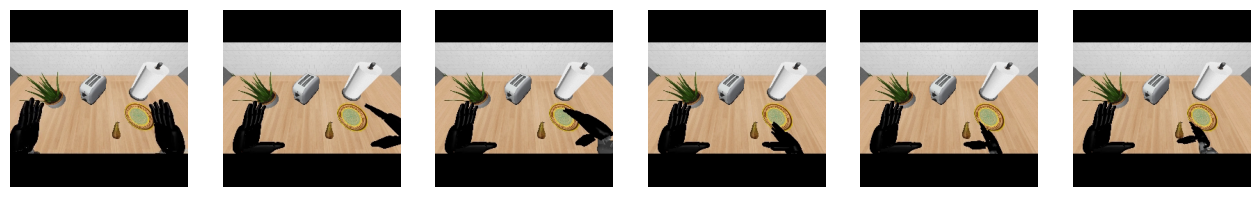

In [8]:
import matplotlib.pyplot as plt

traj_id = 0
max_steps = 150

state_joints_across_time = []
gt_action_joints_across_time = []
images = []

sample_images = 6

for step_count in range(max_steps):
    data_point = dataset.get_step_data(traj_id, step_count)
    state_joints = data_point["state.right_arm"][0]
    gt_action_joints = data_point["action.right_arm"][0]
    
   
    state_joints_across_time.append(state_joints)
    gt_action_joints_across_time.append(gt_action_joints)

    # We can also get the image data
    if step_count % (max_steps // sample_images) == 0:
        image = data_point["video.ego_view"][0]
        images.append(image)

# Size is (max_steps, num_joints == 7)
state_joints_across_time = np.array(state_joints_across_time)
gt_action_joints_across_time = np.array(gt_action_joints_across_time)


# Plot the joint angles across time
fig, axes = plt.subplots(nrows=7, ncols=1, figsize=(8, 2*7))

for i, ax in enumerate(axes):
    ax.plot(state_joints_across_time[:, i], label="state joints")
    ax.plot(gt_action_joints_across_time[:, i], label="gt action joints")
    ax.set_title(f"Joint {i}")
    ax.legend()

plt.tight_layout()
plt.show()


# Plot the images in a row
fig, axes = plt.subplots(nrows=1, ncols=sample_images, figsize=(16, 4))

for i, ax in enumerate(axes):
    ax.imshow(images[i])
    ax.axis("off")
    

In [9]:
step_data

{'video.ego_view': array([[[[0, 0, 0],
          [0, 0, 0],
          [0, 0, 0],
          ...,
          [0, 0, 0],
          [0, 0, 0],
          [0, 0, 0]],
 
         [[0, 0, 0],
          [0, 0, 0],
          [0, 0, 0],
          ...,
          [0, 0, 0],
          [0, 0, 0],
          [0, 0, 0]],
 
         [[0, 0, 0],
          [0, 0, 0],
          [0, 0, 0],
          ...,
          [0, 0, 0],
          [0, 0, 0],
          [0, 0, 0]],
 
         ...,
 
         [[0, 0, 0],
          [0, 0, 0],
          [0, 0, 0],
          ...,
          [0, 0, 0],
          [0, 0, 0],
          [0, 0, 0]],
 
         [[0, 0, 0],
          [0, 0, 0],
          [0, 0, 0],
          ...,
          [0, 0, 0],
          [0, 0, 0],
          [0, 0, 0]],
 
         [[0, 0, 0],
          [0, 0, 0],
          [0, 0, 0],
          ...,
          [0, 0, 0],
          [0, 0, 0],
          [0, 0, 0]]]], dtype=uint8),
 'state.left_arm': array([[-0.01147083,  0.12207967,  0.04229397, -2.1       , -0.014414

In [10]:
step_data['video.ego_view'].shape
step_data['annotation.human.action.task_description']

['pick the pear from the counter and place it in the plate']

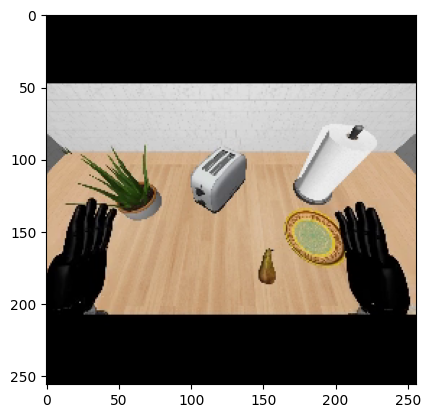

In [11]:
plt.imshow(step_data['video.ego_view'][0])

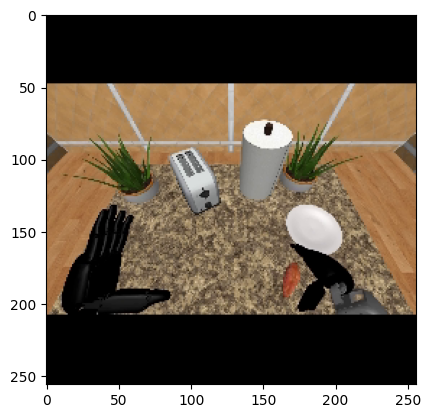

In [12]:
plt.imshow(step_data2['video.ego_view'][0])

Now we can run the policy from the pretrained checkpoint.

In [13]:
predicted_action = policy.get_action(step_data)
for key, value in predicted_action.items():
    print(key, value.shape)

action.left_arm (16, 7)
action.right_arm (16, 7)
action.left_hand (16, 6)
action.right_hand (16, 6)


### Understanding the Action Output

Each joint in the action output has a shape of (16, N) where N is the degree of freedom for the joint.
- 16 represents the action horizon (predictions for timesteps t, t+1, t+2, ..., t+15)

For each arm (left and right):
- 7 arm joints:
  - Shoulder pitch
  - Shoulder roll
  - Shoulder yaw
  - Elbow pitch
  - Wrist yaw
  - Wrist roll
  - Wrist pitch

For each hand (left and right):
- 6 finger joints:
  - Little finger
  - Ring finger
  - Middle finger
  - Index finger
  - Thumb rotation
  - Thumb bending

For the waist
- 3 joints:
  - torso waist yaw
  - torso waist pitch
  - torso waist roll


In [14]:
import copy

action.left_arm (16, 7)
action.right_arm (16, 7)
action.left_hand (16, 6)
action.right_hand (16, 6)

=== Language sensitivity (same obs, different prompt) ===
action.left_arm
ta: torch.Size([112]), tb: torch.Size([112])
action.left_arm: cosine=0.991751, l1_mean=0.074541
action.right_arm
ta: torch.Size([112]), tb: torch.Size([112])
action.right_arm: cosine=0.856244, l1_mean=0.307420
action.left_hand
ta: torch.Size([96]), tb: torch.Size([96])
action.left_hand: cosine=0.321839, l1_mean=0.009926
action.right_hand
ta: torch.Size([96]), tb: torch.Size([96])
action.right_hand: cosine=0.459978, l1_mean=1.275873


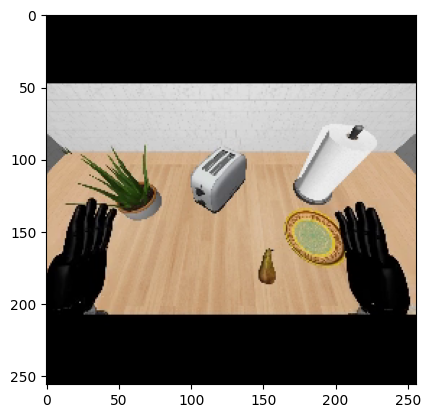

In [ ]:
predicted_action = policy.get_action(step_data)
for key, value in predicted_action.items():
    print(key, value.shape)
    
lang_key = "annotation.human.action.task_description"
if lang_key not in step_data:
    print(f"[WARN] Language key '{lang_key}' not found. Available keys: {list(step_data.keys())}")
else:
    sample_a = copy.deepcopy(step_data)
    sample_b = copy.deepcopy(step_data)
    plt.imshow(sample_a['video.ego_view'][0])
    sample_a[lang_key] = ["pick the pear from the counter and place it in the plate."]
    sample_b[lang_key] = ["don't move. please stop."]

    pred_a = policy.get_action(sample_a)
    pred_b = policy.get_action(sample_b)
    print("\n=== Language sensitivity (same obs, different prompt) ===")
    for key in pred_a.keys():
        print(key)
        ta = torch.as_tensor(pred_a[key], dtype=torch.float32).flatten()
        tb = torch.as_tensor(pred_b[key], dtype=torch.float32).flatten()
        print(f"ta: {ta.shape}, tb: {tb.shape}")
        cos = torch.dot(ta, tb) / (torch.norm(ta) * torch.norm(tb) + 1e-8)
        l1 = torch.mean(torch.abs(ta - tb))
        print(f"{key}: cosine={cos.item():.6f}, l1_mean={l1.item():.6f}")